# CalCOFI data

All CalCOFI data downloaded from CalCOFI Bottle data: https://calcofi.org/data/oceanographic-data/bottle-database/ 

**NOTE** download both Cast Table and Bottle Table to line up metadata correctly

Once both the cast and bottle data were downloaded and imported into python, the dataframes were reduced and a single datetime column created.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [2]:
Calcofi_btl = pd.read_excel(r'CalCOFI_Database_194903-202105_csv_16October2023\194903-202105_Bottle.xlsx')#chl files
Calcofi_btl = Calcofi_btl[['Cst_Cnt','Sta_ID', 'Depthm',  'ChlorA', 'Chlqua','R_Depth']] #reduce to only needed columns

#since bottle data has no datetime, lat, or lon, need to load in CalCOFI meta data and match up to bottle data
Calcofi_cast = pd.read_excel(r'CalCOFI_Database_194903-202105_csv_16October2023\194903-202105_Cast.xlsx')
Calcofi_cast = Calcofi_cast[['Cst_Cnt', 'Cruise', 'Sta_ID', 'Sta_Code', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Data_Type']]

#create datetime column
Calcofi_cast['Date'] = Calcofi_cast['Date'].astype(str)
Calcofi_cast['Time'] = Calcofi_cast['Time'].astype(str)
Calcofi_cast['Date'] = Calcofi_cast['Date'].str.slice(0, 10)  # Keeps only 'YYYY-MM-DD'
datetime_str = Calcofi_cast['Date'] + ' ' + Calcofi_cast['Time']
Calcofi_cast['datetime'] = pd.to_datetime(datetime_str, errors='coerce')

FileNotFoundError: [Errno 2] No such file or directory: 'CalCOFI_Database_194903-202105_csv_16October2023\\194903-202105_Bottle.xlsx'

Since the bottle data with chlorophyll values does not have datetime, lat, or lon data, need to match the bottle data with the cast data by matching up the cast count (Cst_Cnt). 

- According to the CalCOFI website, Cst_Cnt = All CalCOFI casts ever conducted, consecutively numbered. So by matching up the two dataframes by Cst_Cnt we're able to add datetime, lat, and lon to the bottle data.

In [ ]:
#to match up the metadata (Calcofi_cast) with the bottle data (Calcofi_btl), match by cast since each cast is unique
Calcofi_btl['lat'] = Calcofi_btl['Cst_Cnt'].map(Calcofi_cast.set_index('Cst_Cnt')['Lat_Dec']) # map a lat column to where Cst_counts match, lat will be a copy of Lat_Dec
Calcofi_btl['lon'] = Calcofi_btl['Cst_Cnt'].map(Calcofi_cast.set_index('Cst_Cnt')['Lon_Dec']) #same for lon
Calcofi_btl['datetime'] = Calcofi_btl['Cst_Cnt'].map(Calcofi_cast.set_index('Cst_Cnt')['datetime']) #same for datetime


In [ ]:
#for this algorithm, only want data from 2000 on and above 150 meters 
Calcofi_btl = Calcofi_btl[Calcofi_btl['datetime'] > pd.to_datetime('2000-01-01')]
Calcofi_btl=Calcofi_btl.loc[Calcofi_btl['Depthm']<=150].reset_index(drop=True) 

#Remove questionable and bad data (data flagged 8 and 9 in column chlqua)
Calcofi_btl = Calcofi_btl[Calcofi_btl['Chlqua'] != 9]
Calcofi_btl = Calcofi_btl[Calcofi_btl['Chlqua'] != 8]

## HPLC flags
While it seems like CalCOFI uses HPLC methods for some variables, based on https://calcofi.info/index.php/field-work/bottle-sampling, it doesn't seem like they use HPLC for chlorophyll

In [ ]:
Calcofi_btl['HPLC'] = 1

## Triplicate flags
Similar to the SeaBASS triplicate flags, the number of unique Cst_Cnt, Depthm, datetime, lat, and lon were recorded in the column 'unique'. Based on inspecting the column, there are no samples that were recorded 3 times, so no triplicate samples.

In [ ]:
counts_series = Calcofi_btl[['Cst_Cnt','Depthm','datetime','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='unique')
Calcofi_btl = pd.merge(Calcofi_btl, counts_df, on=['Cst_Cnt','Depthm','datetime','lat','lon'], how='left') #add frequency column to original dataframe
#based on inspecting the Calcofi_btl dataframe, no triplicates recorded (i.e. no unique values = 3)
Calcofi_btl['triplicate'] = 1

In [ ]:
#rename columns to match seabass columns
Calcofi_btl=Calcofi_btl.rename(columns={'Cst_Cnt':'cast', 'Sta_ID':'station','ChlorA':'chl','Depthm':'depth'})
Calcofi_btl = Calcofi_btl[['datetime','lat', 'lon','chl', 'cast', 'station', 'depth','HPLC', 'triplicate']]

In [ ]:
#final metadata compilation and save the dataframe!
calcofi_nSB['identifier_product_doi'] = 'https://calcofi.org'
calcofi_nSB['source'] = 'CalCOFI'
calcofi_nSB=calcofi_nSB[['datetime', 'lat', 'lon', 'chl', 'depth','cast', 'station', 'HPLC','triplicate', 'identifier_product_doi', 'source']]
#calcofi_nSB.to_excel('calcofi_chl_qc.xlsx', index = False)


Yay you're done compiling and organizing CalCOFI data to best match the seabass data! 

The data were obtained from the California Cooperative Oceanic Fisheries Investigations and is publically available at calcofi.org

## Plots

In [3]:
CalCOFI = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\calcofi_chl_qc.xlsx')

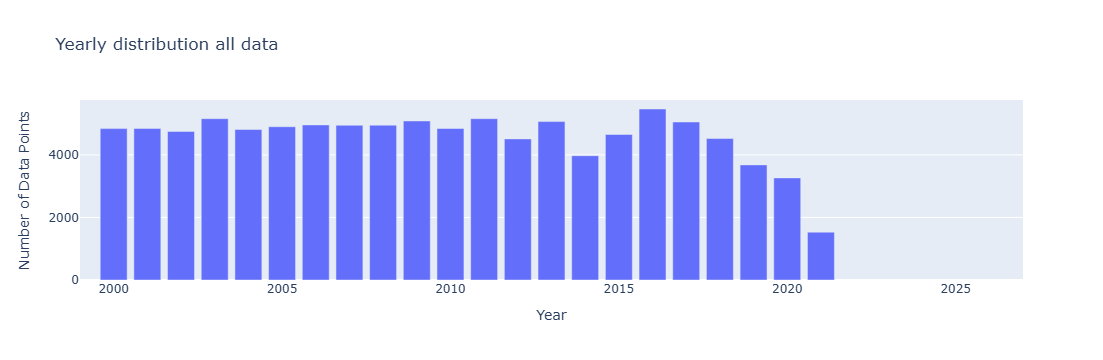

In [4]:
year_test=CalCOFI.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

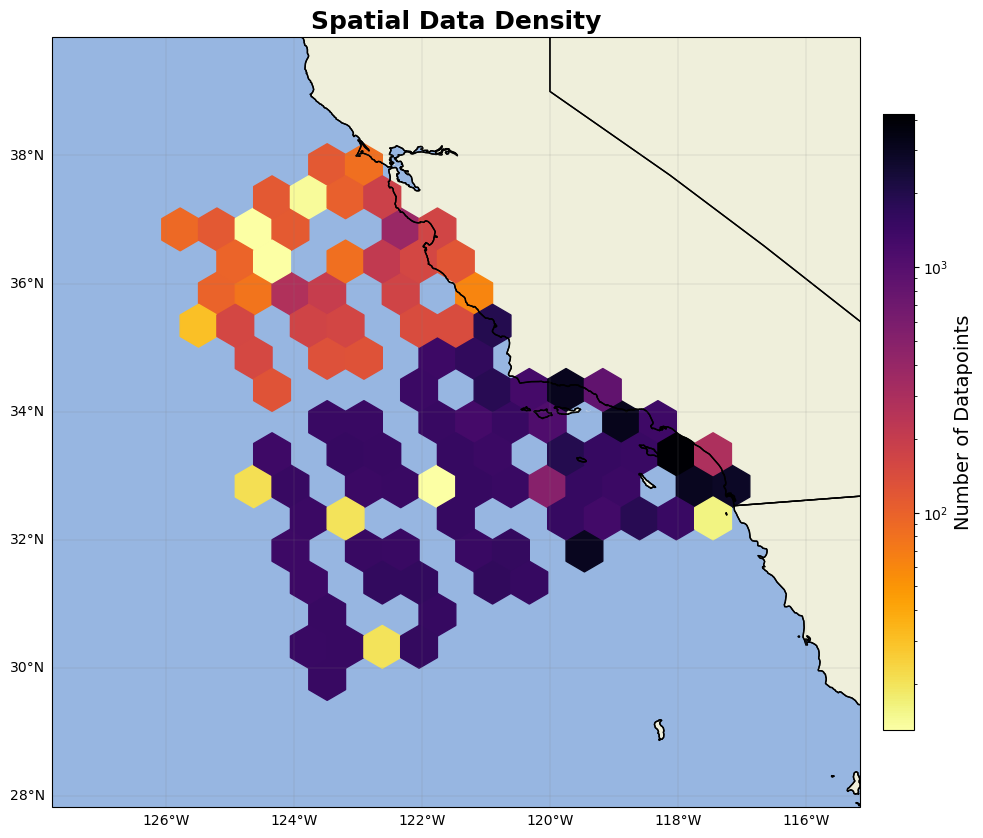

In [5]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=15, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()